In [36]:
import numpy as np 
import matplotlib.pyplot as plt 

In [37]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])

y = np.array([0, 1, 1, 0])

In [38]:
w1 = np.random.rand(2, 2)
b1 = np.zeros(2)

w2 = np.random.rand(2, 1)
b2 = np.zeros(1)

In [39]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def derivative_sigmoid(a):
    return a * (1 - a)

In [40]:
epochs = 10000
lr = 0.1

In [41]:
for epoch in range(epochs):
    for i in range(len(X)):
        x = X[i]
        target = y[i]

        h1 = (x @ w1) + b1
        a1 = sigmoid(h1)

        h2 = (a1 @ w2) + b2
        a2 = sigmoid(h2)

        loss = np.mean(np.square(target - a2))

        o2 = (a2 - target) * derivative_sigmoid(a2)
        o1 = derivative_sigmoid(a1) * (w2 @ o2)

        w2 -= lr * np.outer(a1, o2)
        b2 -= lr * o2
        w1 -= lr * np.outer(x, o1)
        b1 -= lr * o1

print("W2: ", w2)
print("B2: ", b2)
print("W1: ", w1)
print("B1: ", b1)

W2:  [[-8.17077635]
 [ 7.57416924]]
B2:  [-3.43642378]
W1:  [[3.81445254 5.75291377]
 [3.81552263 5.7619526 ]]
B1:  [-5.84550727 -2.41209478]


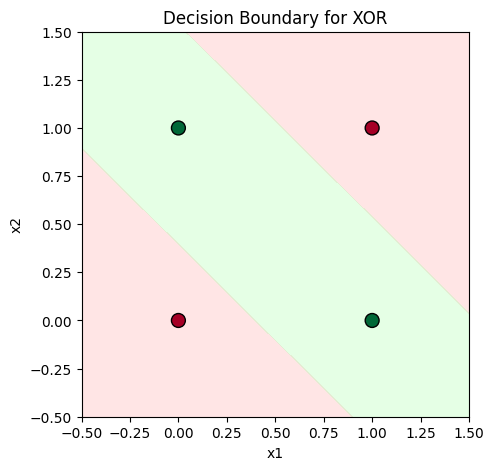

In [42]:
plt.figure(figsize=(5, 5))
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Forward pass for grid
a1_grid = sigmoid(np.dot(grid, w1) + b1)
a2_grid = sigmoid(np.dot(a1_grid, w2) + b2)
Z = a2_grid.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=["#FFAAAA", "#AAFFAA"])
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=100, cmap=plt.cm.RdYlGn)
plt.title("Decision Boundary for XOR")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()